<b> Perform Data Analysis using Pandas, Matplotlib and Seaborn for the mentioned Datasets.

<b> 1. Netflix Analysis

Problem Statement : Explore out the briefer analysis on Netflix Dataset with an access to noticeable feature attributes for Movies/TV Shows with Viewership Score and present the justifiable insights in points along with an overall summary.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

%matplotlib inline

import warnings
warnings.filterwarnings('ignore')

In [2]:
# read the data into a pandas Dataframe object
df = pd.read_csv('netflix daily top 10.csv')

In [3]:
# to show number of rows and columns in csv file
df.shape

(7100, 10)

In [4]:
# to show the top 6 rows of Datasets
df.head(6)

,As of,Rank,Year to Date Rank,Last Week Rank,Title,Type,Netflix Exclusive,Netflix Release Date,Days In Top 10,Viewership Score
0,2020-04-01,1,1,1,"Tiger King: Murder, Mayhem …",TV Show,Yes,"Mar 20, 2020",9,90
1,2020-04-01,2,2,-,Ozark,TV Show,Yes,"Jul 21, 2017",5,45
2,2020-04-01,3,3,2,All American,TV Show,NaN,"Mar 28, 2019",9,76
3,2020-04-01,4,4,-,Blood Father,Movie,NaN,"Mar 26, 2020",5,30
4,2020-04-01,5,5,4,The Platform,Movie,Yes,"Mar 20, 2020",9,55
5,2020-04-01,6,6,-,Car Masters: Rust to Riches,TV Show,Yes,"Sep 14, 2018",4,14


In [5]:
# to show the last 5 rows of Datasets
df.tail()

,As of,Rank,Year to Date Rank,Last Week Rank,Title,Type,Netflix Exclusive,Netflix Release Date,Days In Top 10,Viewership Score
7095,2022-03-11,6,5,1,Worst Roommate Ever,TV Show,Yes,"Mar 1, 2022",10,81
7096,2022-03-11,7,7,2,Vikings: Valhalla,TV Show,Yes,"Feb 25, 2022",14,100
7097,2022-03-11,8,8,-,Shooter,Movie,NaN,"Aug 1, 2014",3,7
7098,2022-03-11,9,9,7,Shrek 2,Movie,NaN,"Mar 1, 2022",10,33
7099,2022-03-11,10,10,-,Shrek,Movie,NaN,"May 1, 2018",7,12


In [6]:
# to show the information of above Datasets
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7100 entries, 0 to 7099
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   As of                 7100 non-null   object
 1   Rank                  7100 non-null   int64 
 2   Year to Date Rank     7100 non-null   object
 3   Last Week Rank        7100 non-null   object
 4   Title                 7100 non-null   object
 5   Type                  7100 non-null   object
 6   Netflix Exclusive     4599 non-null   object
 7   Netflix Release Date  7100 non-null   object
 8   Days In Top 10        7100 non-null   int64 
 9   Viewership Score      7100 non-null   int64 
dtypes: int64(3), object(7)
memory usage: 554.8+ KB


In [7]:
# convert string to a datetime column
df['Netflix Release Date'] = pd.to_datetime(df['Netflix Release Date'])

In [8]:
# describe function is used to show calculated values of object datatype
df.describe(include = 'object')

,As of,Year to Date Rank,Last Week Rank,Title,Type,Netflix Exclusive
count,7100,7100,7100,7100,7100,4599
unique,710,11,11,645,4,1
top,2020-04-01,-,-,Cocomelon,TV Show,Yes
freq,10,859,3968,428,4446,4599


In [9]:
# drop the duplicates values and storing the unique values in df1
sort = df.sort_values(by = 'Viewership Score', ascending = True)
df1 = sort.drop_duplicates(subset = 'Title', keep = 'last')
# to show rows and columns
df1.shape

(645, 10)

In [10]:
# used describe() for object datatype
df1.describe(include='object')

,As of,Year to Date Rank,Last Week Rank,Title,Type,Netflix Exclusive
count,645,645,645,645,645,409
unique,444,11,11,645,4,1
top,2022-03-11,9,-,The Lucky One,Movie,Yes
freq,10,116,365,1,355,409


In [11]:
# Describbe function is used for calculating some statistical data like percentile, mean and std of the numerical value of the above Dataset
df1.describe()

,Rank,Days In Top 10,Viewership Score
count,645.000000,645.000000,645.000000
mean,8.734884,11.181395,61.809302
std,1.464733,19.986244,97.730724
min,1.000000,1.000000,1.000000
25%,8.000000,4.000000,15.000000
50%,9.000000,7.000000,33.000000
75%,10.000000,12.000000,68.000000
max,10.000000,428.000000,1474.000000


In [12]:
# to check for missing values
df1.isnull()

,As of,Rank,Year to Date Rank,Last Week Rank,Title,Type,Netflix Exclusive,Netflix Release Date,Days In Top 10,Viewership Score
6739,False,False,False,False,False,False,True,False,False,False
5099,False,False,False,False,False,False,False,False,False,False
729,False,False,False,False,False,False,True,False,False,False
6429,False,False,False,False,False,False,True,False,False,False
6449,False,False,False,False,False,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...
5187,False,False,False,False,False,False,False,False,False,False
6996,False,False,False,False,False,False,False,False,False,False
6678,False,False,False,False,False,False,True,False,False,False
5347,False,False,False,False,False,False,True,False,False,False


In [13]:
# replace values '-' to 'nan'
df1.replace('-', np.nan, inplace = True)

In [14]:
# sum of null value in each column
df1.isnull().sum()  

As of                     0
Rank                      0
Year to Date Rank        55
Last Week Rank          365
Title                     0
Type                      0
Netflix Exclusive       236
Netflix Release Date      0
Days In Top 10            0
Viewership Score          0
dtype: int64

In [15]:
# to show the all column name
df.columns

Index(['As of', 'Rank', 'Year to Date Rank', 'Last Week Rank', 'Title', 'Type',
       'Netflix Exclusive', 'Netflix Release Date', 'Days In Top 10',
       'Viewership Score'],
      dtype='object')

In [16]:
# to count the unique values of 'Type' contents
count = df1.Type.value_counts()   
count

Movie              355
TV Show            283
Stand-Up Comedy      6
Concert/Perf…        1
Name: Type, dtype: int64

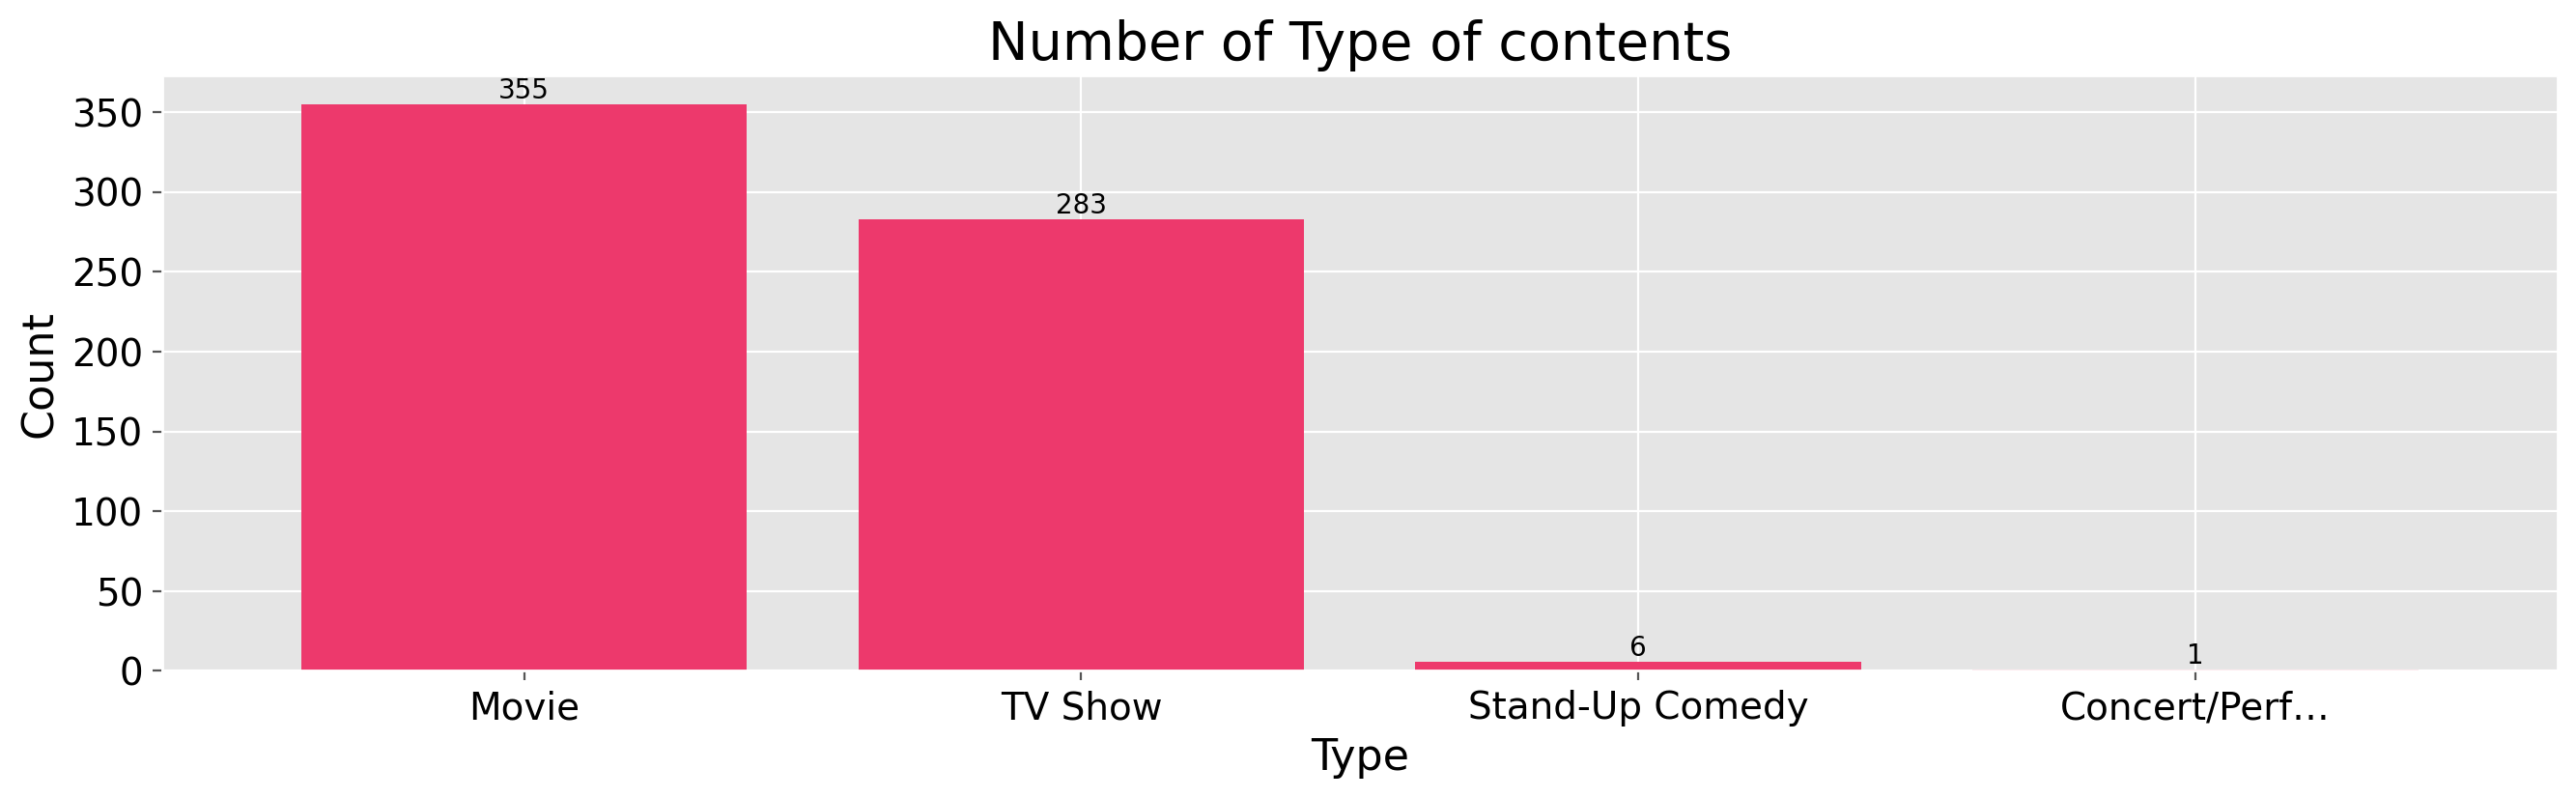

In [17]:
plt.style.use('ggplot')
plt.figure(figsize = (16,4), dpi = 200)
ax = count.plot(kind = 'bar', color = '#ed396c', width = 0.8)
for bars in ax.containers :
    ax.bar_label(bars)

plt.xticks(rotation = 360, size = 14, color = 'black')
plt.yticks(size = 14, color = 'black')
plt.xlabel('Type', size = 16)
plt.ylabel('Count', size = 16)
plt.title("Number of Type of contents",size = 20, color = 'black')
plt.show()

<b> Number of Movies released is Highest and the 2nd Highest is TV Show in 'Type' category on Netflix, which is 355 and 283 respectively

In [18]:
# set the parameters that control the scaling of plot elements
sns.set(rc = {'axes.facecolor' : '#0fdbc7',
             'axes.grid' : False,
             'axes.labelsize'   : 14,
             'axes.labelcolor'  : 'black',
             'axes.titlesize'   : 20,
             'axes.titlecolor'  : 'black',
             'figure.facecolor' : '#7bb5af',
             'xtick.labelsize'  : 12,
             'xtick.color'      : 'black',
             'ytick.labelsize'  : 12,
             'ytick.color'      : 'black'})

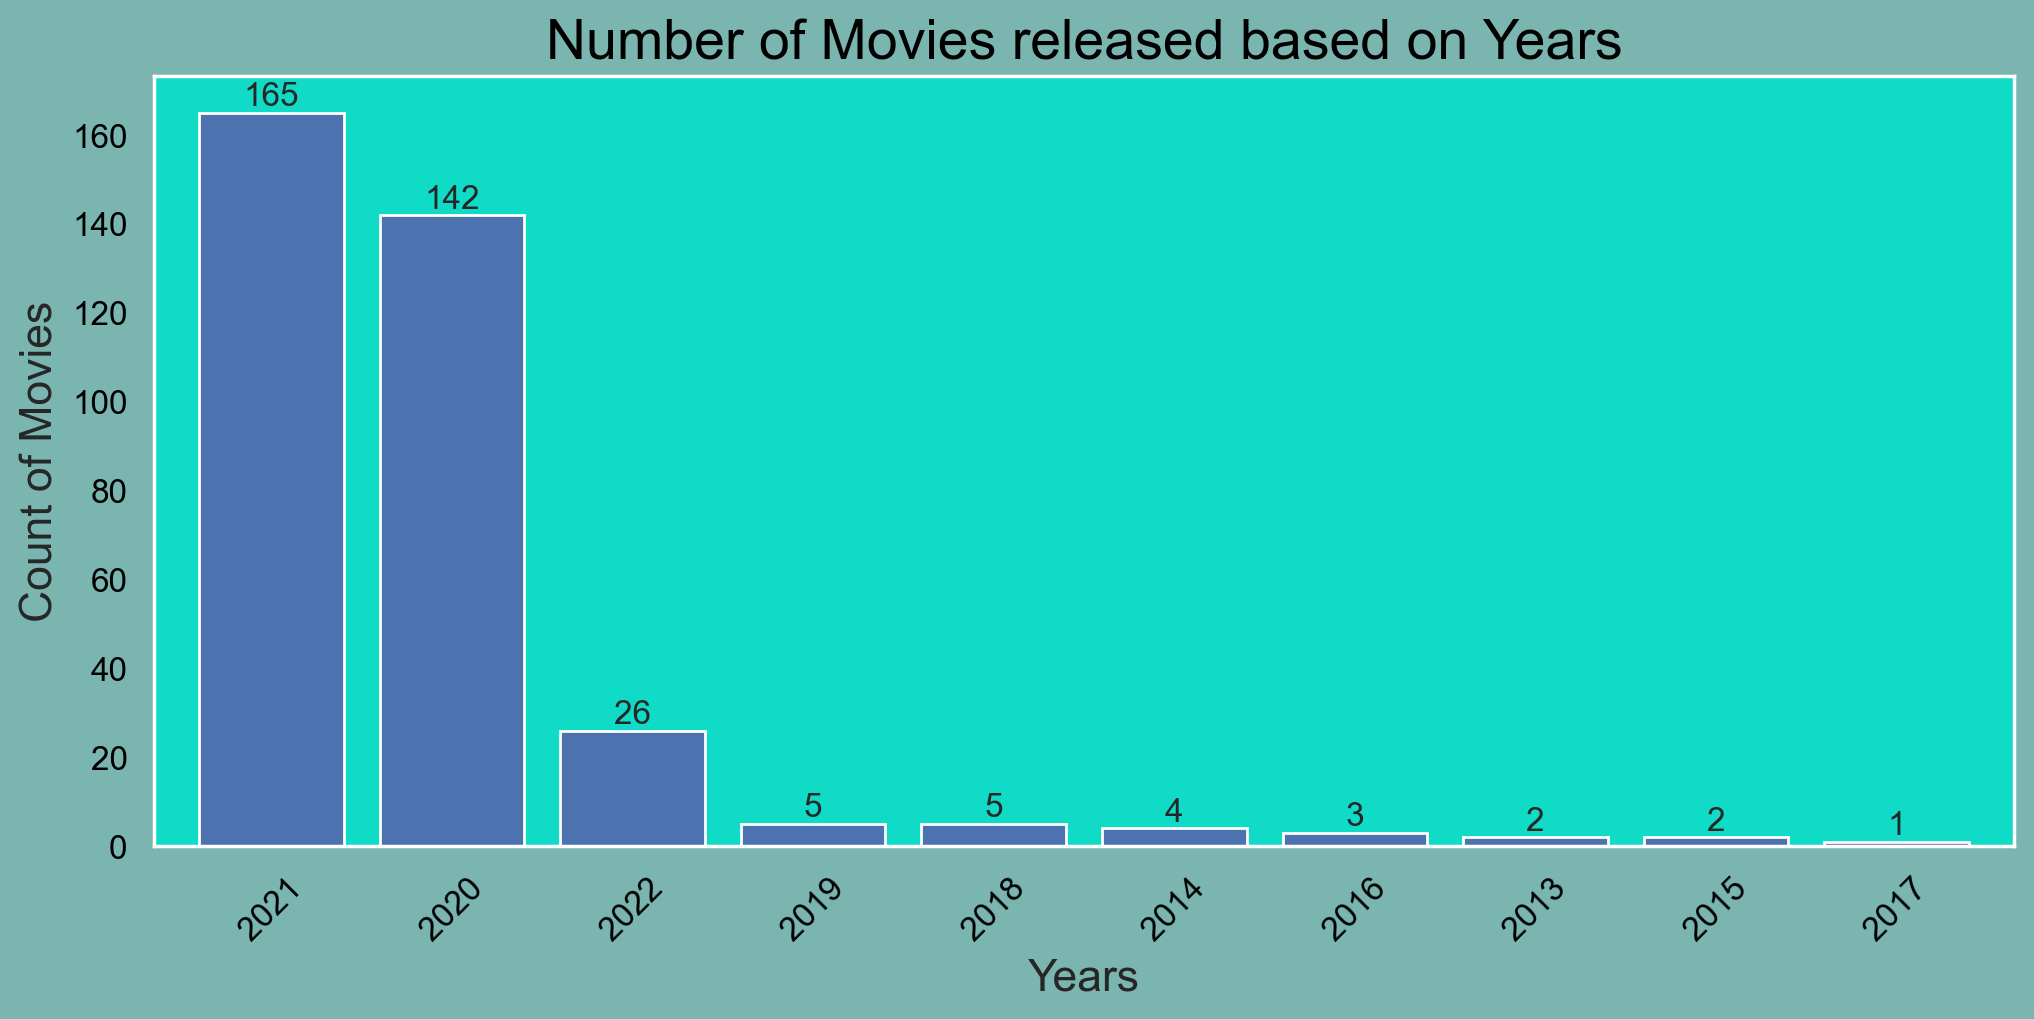

In [19]:
x = df1.loc[df1['Type'] == 'Movie']
movies_released = x['Netflix Release Date'].dt.year.value_counts().sort_values(ascending = False)

plt.figure(figsize = (12,5), dpi = 200)
ax = movies_released.plot(kind = 'bar', width = 0.8)
for bars in ax.containers :
    ax.bar_label(bars)
    
plt.xticks(rotation = 45)
plt.xlabel('Years', size = 16)
plt.ylabel('Count of Movies', size = 16)
plt.title("Number of Movies released based on Years")
plt.show()

<b> Highest number of Movies released based on Years in 2021, which is 165

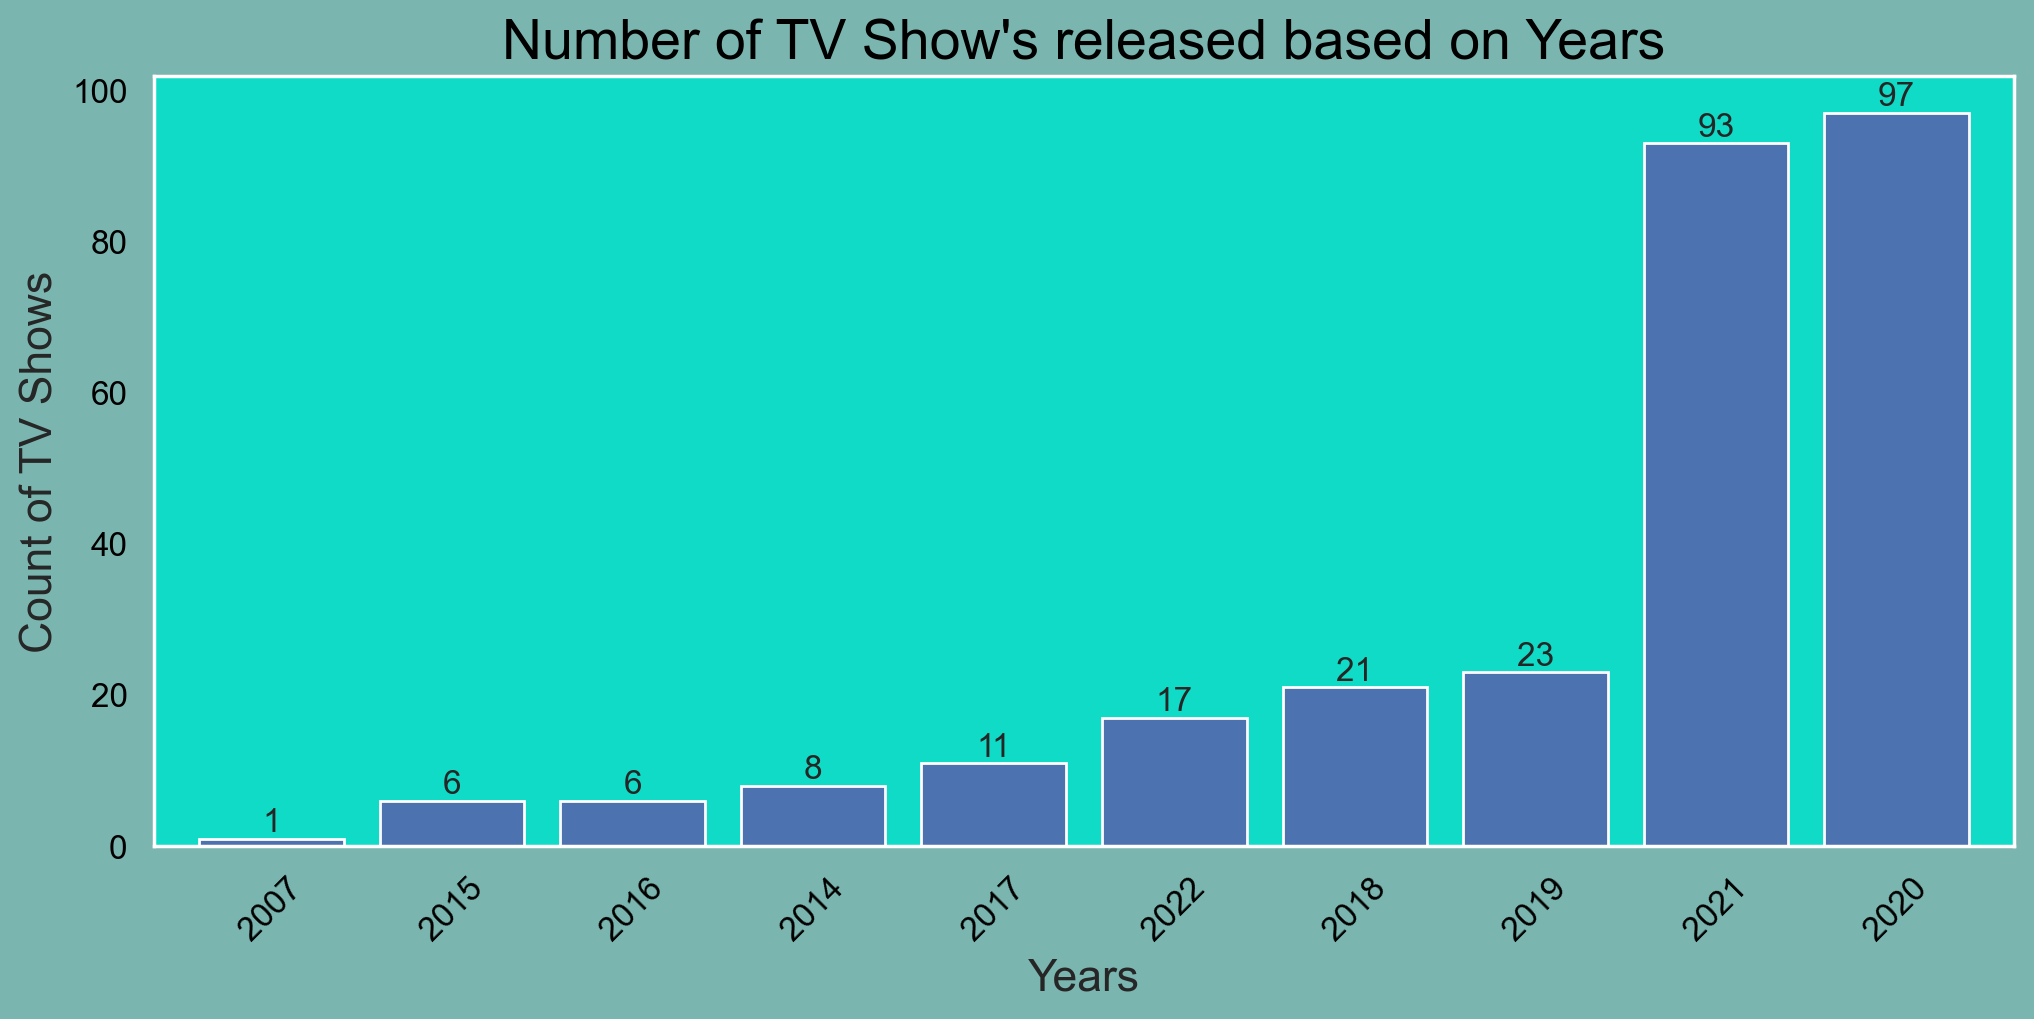

In [20]:
x = df1.loc[df1['Type'] == 'TV Show']
tv_shows_released = x['Netflix Release Date'].dt.year.value_counts().sort_values(ascending = True)

plt.figure(figsize = (12,5), dpi = 200)
ax = tv_shows_released.plot(kind = 'bar', width = 0.8)
for bars in ax.containers :
    ax.bar_label(bars)
    
plt.xticks(rotation = 45)
plt.xlabel('Years', size = 16)
plt.ylabel("Count of TV Shows", size = 16)
plt.title("Number of TV Show's released based on Years")
plt.show()

<b> Highest number of TV Shows based on Years released in 2020, which is 97

In [21]:
df1["Netflix Exclusive"].fillna("No", inplace = True)
df1["Netflix Exclusive"].value_counts()

Yes    409
No     236
Name: Netflix Exclusive, dtype: int64

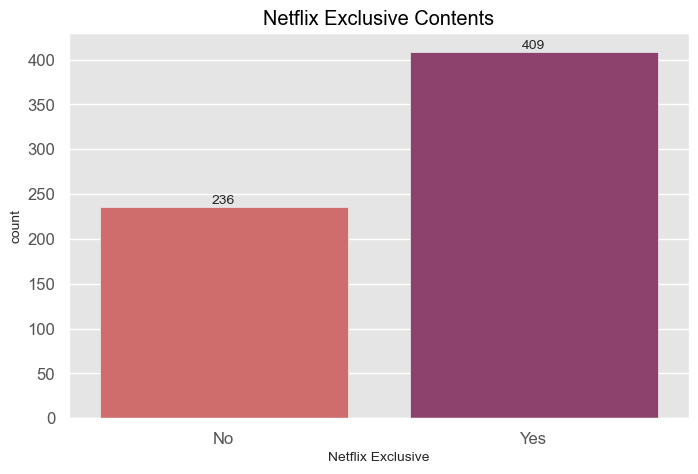

In [22]:
plt.style.use('ggplot')
plt.figure(figsize = (8,5), dpi = 100)
ax = sns.countplot(x = 'Netflix Exclusive', data = df1, palette = "flare")
for bars in ax.containers:
    ax.bar_label(bars)  
       
plt.title('Netflix Exclusive Contents')
plt.show()

<b> Number of Netflix Exclusive contents is 409

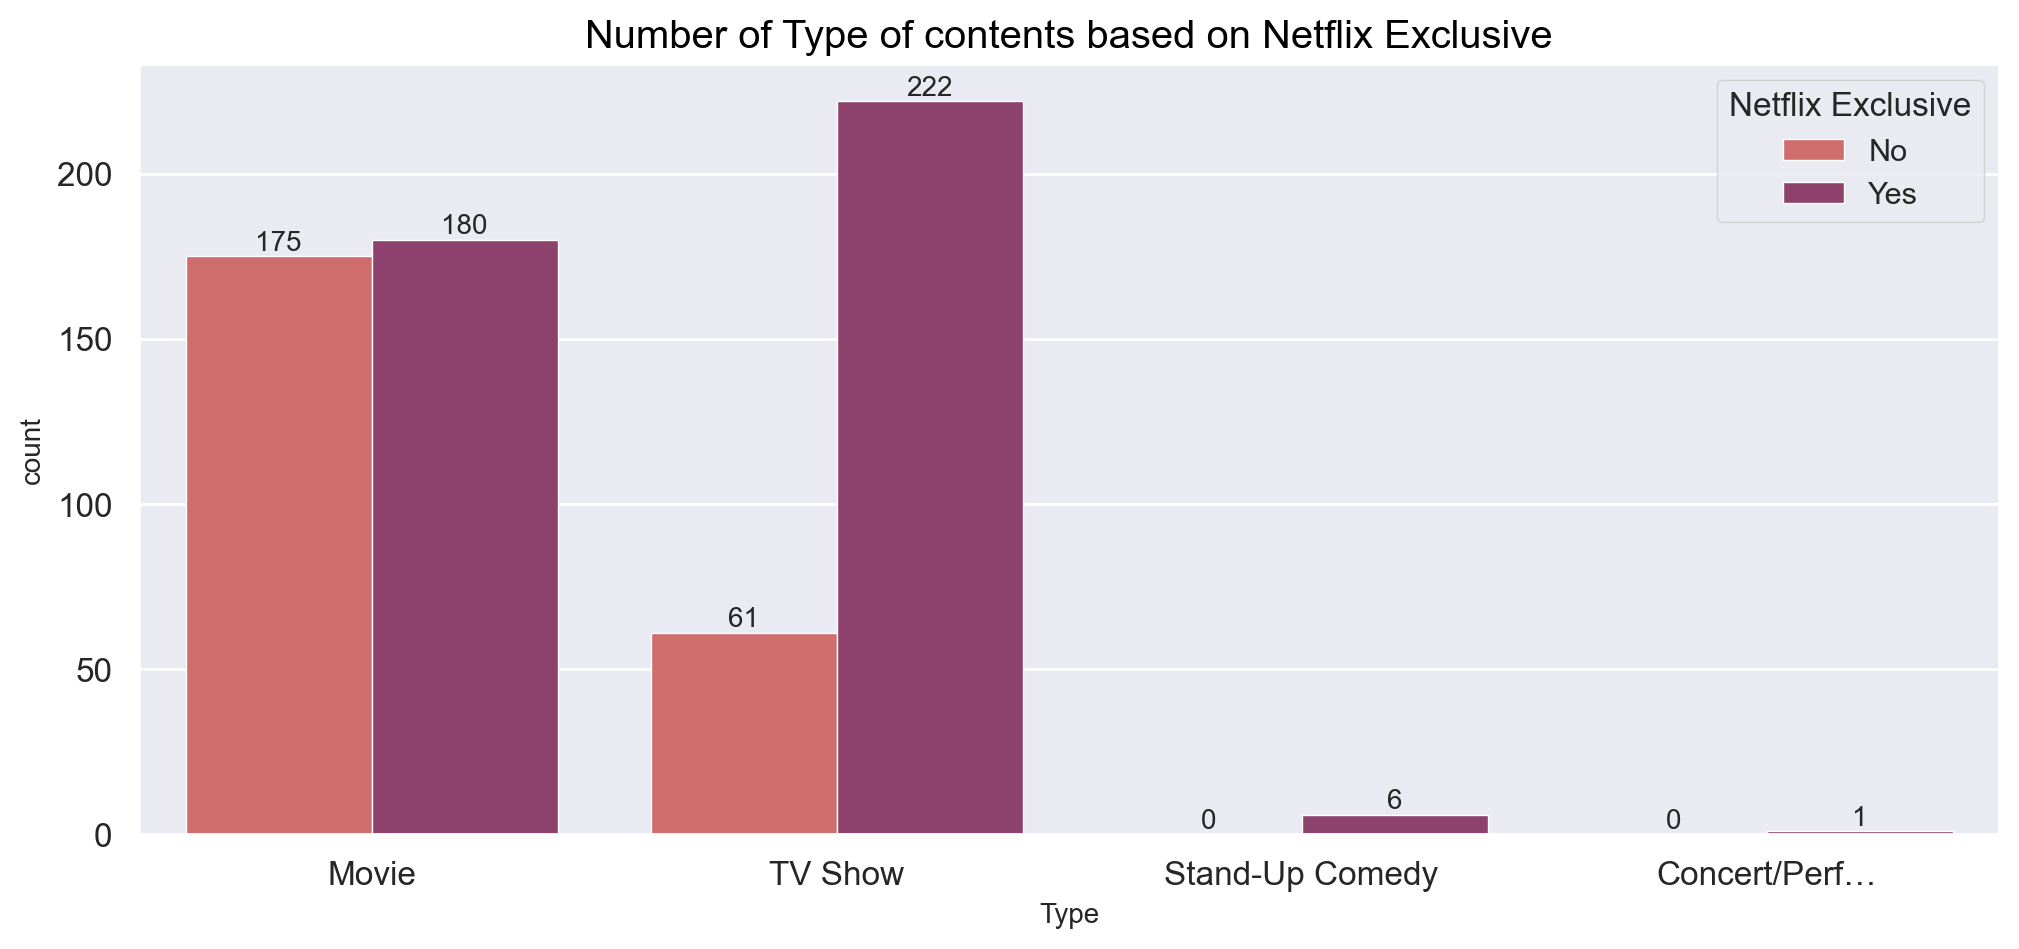

In [23]:
sns.set_style("darkgrid")
plt.figure(figsize = (12,5), dpi = 200)
ax = sns.countplot(x = 'Type', hue = 'Netflix Exclusive' , data = df1, palette = "flare")
for bars in ax.containers:
    ax.bar_label(bars)
    
plt.title("Number of Type of contents based on Netflix Exclusive", )
plt.show()

<b> Number of TV Shows is released on Netflix exclusive is more than the other Type, which is 222
    
<b> Number of Movies is released on Non Netflix exclusive is more than the other Type, which is 175

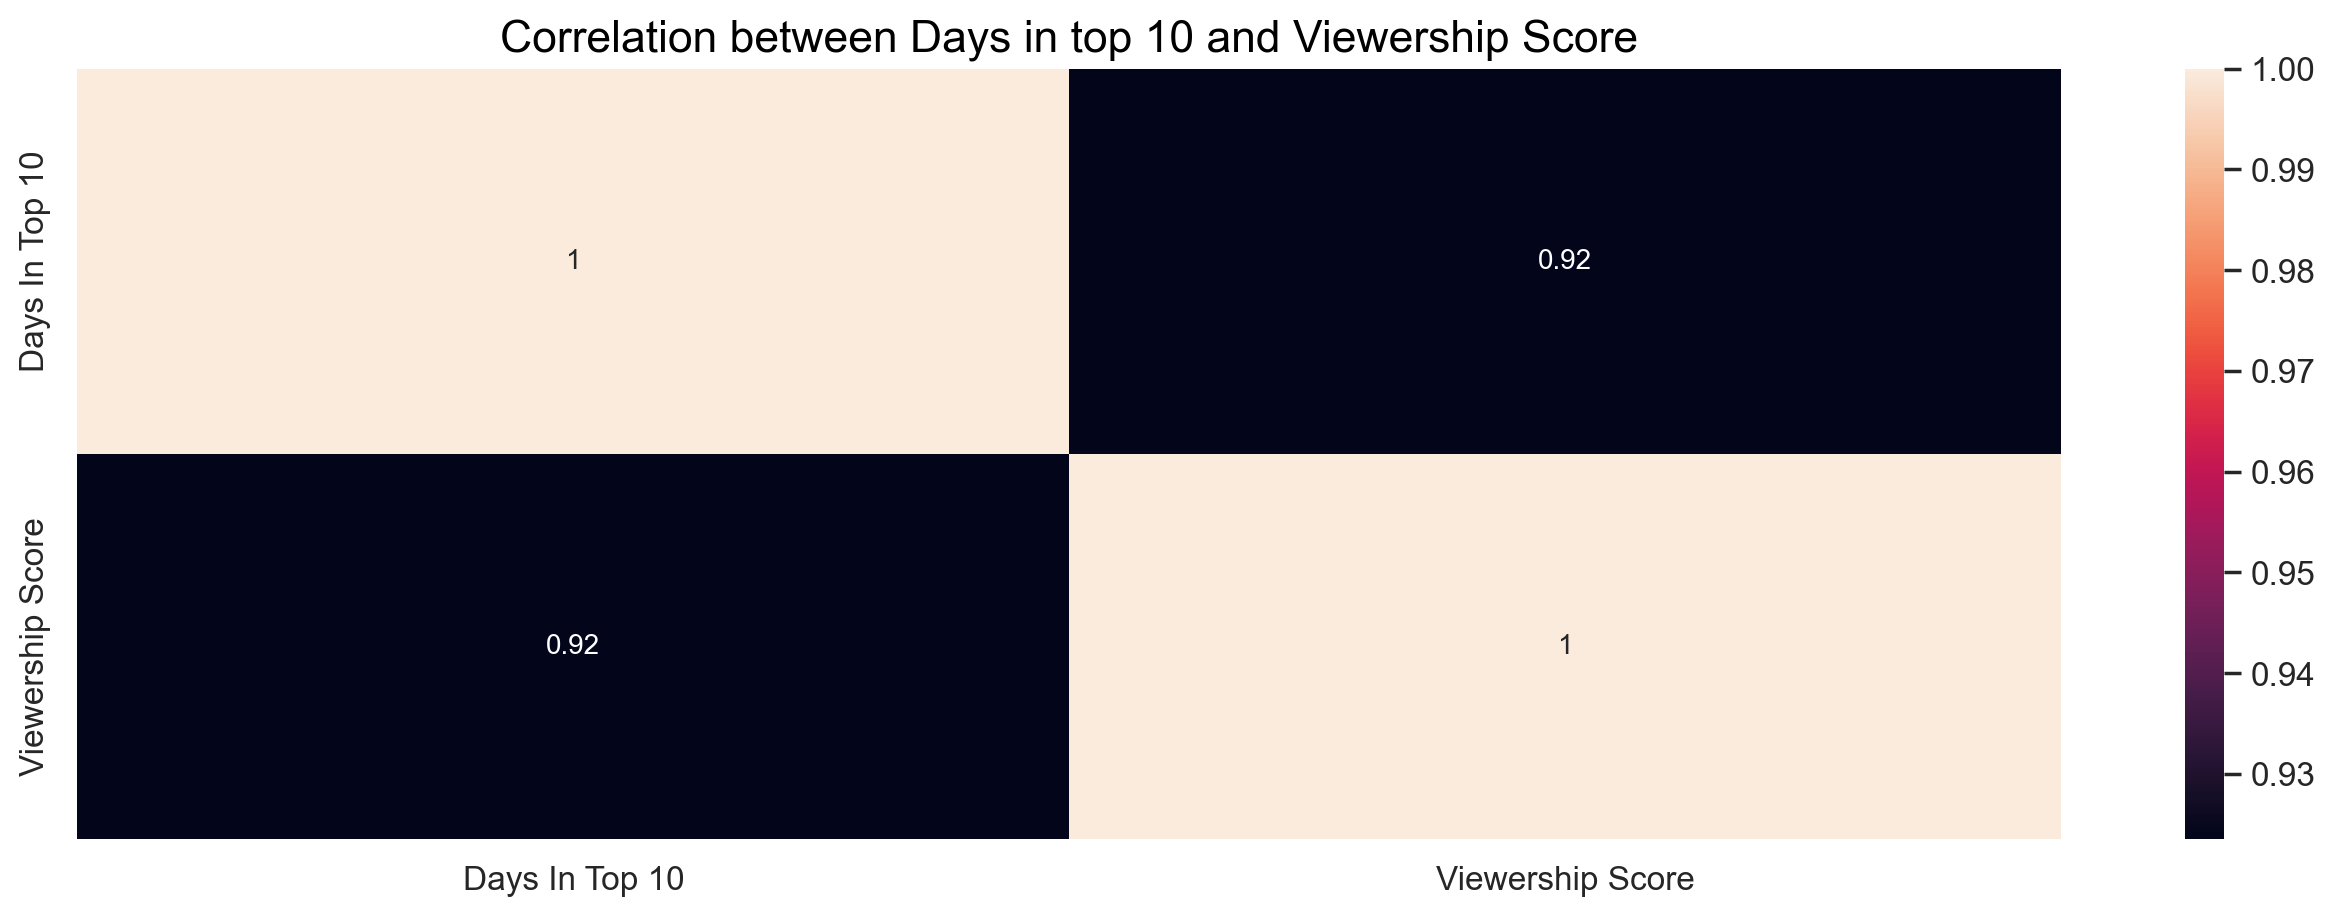

In [24]:
plt.figure(figsize = (16,5), dpi = 200)
sns.heatmap(df1[['Days In Top 10','Viewership Score']].corr(), annot = True)
plt.title('Correlation between Days in top 10 and Viewership Score', size = 16)
plt.show()

<b> we can see that correlation between 'Days In Top 10' and 'Viwership Score', whenever 'Days In Top 10' is high 'Viwership Score' is also high.

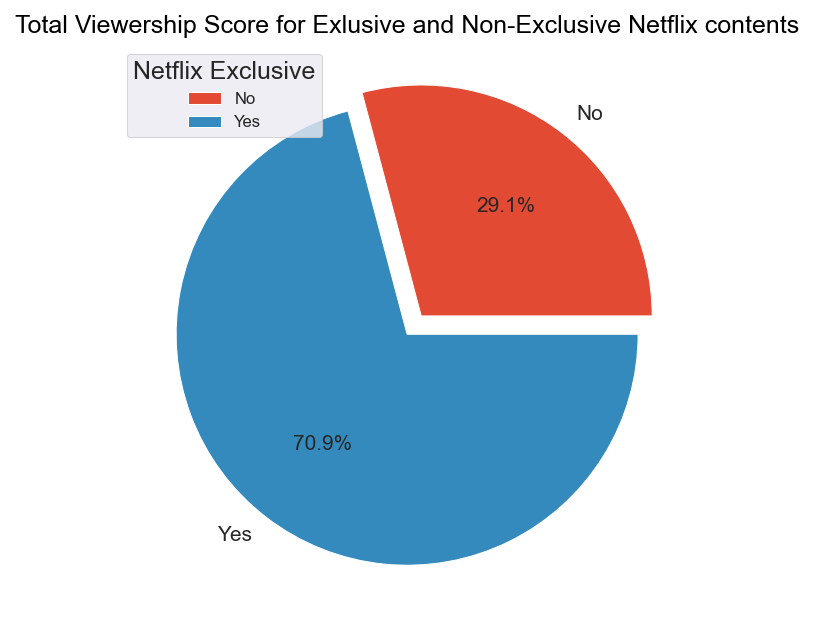

In [25]:
x = df1.groupby(['Netflix Exclusive'])['Viewership Score'].sum()
labels = ['No','Yes']
explode=(0.1,0)
plt.figure(figsize = (12,5), dpi = 150)
plt.pie(x, labels = labels, autopct='%0.1f%%', explode = explode, labeldistance = 1.1, textprops = {'fontsize' : 10})
plt.legend(labels,title = 'Netflix Exclusive', loc = 2, fontsize = 8)
plt.title('Total Viewership Score for Exlusive and Non-Exclusive Netflix contents', size = 12)
plt.show()

<b> Total ViwerShip Score on Netflix Exclusive is 70.9%

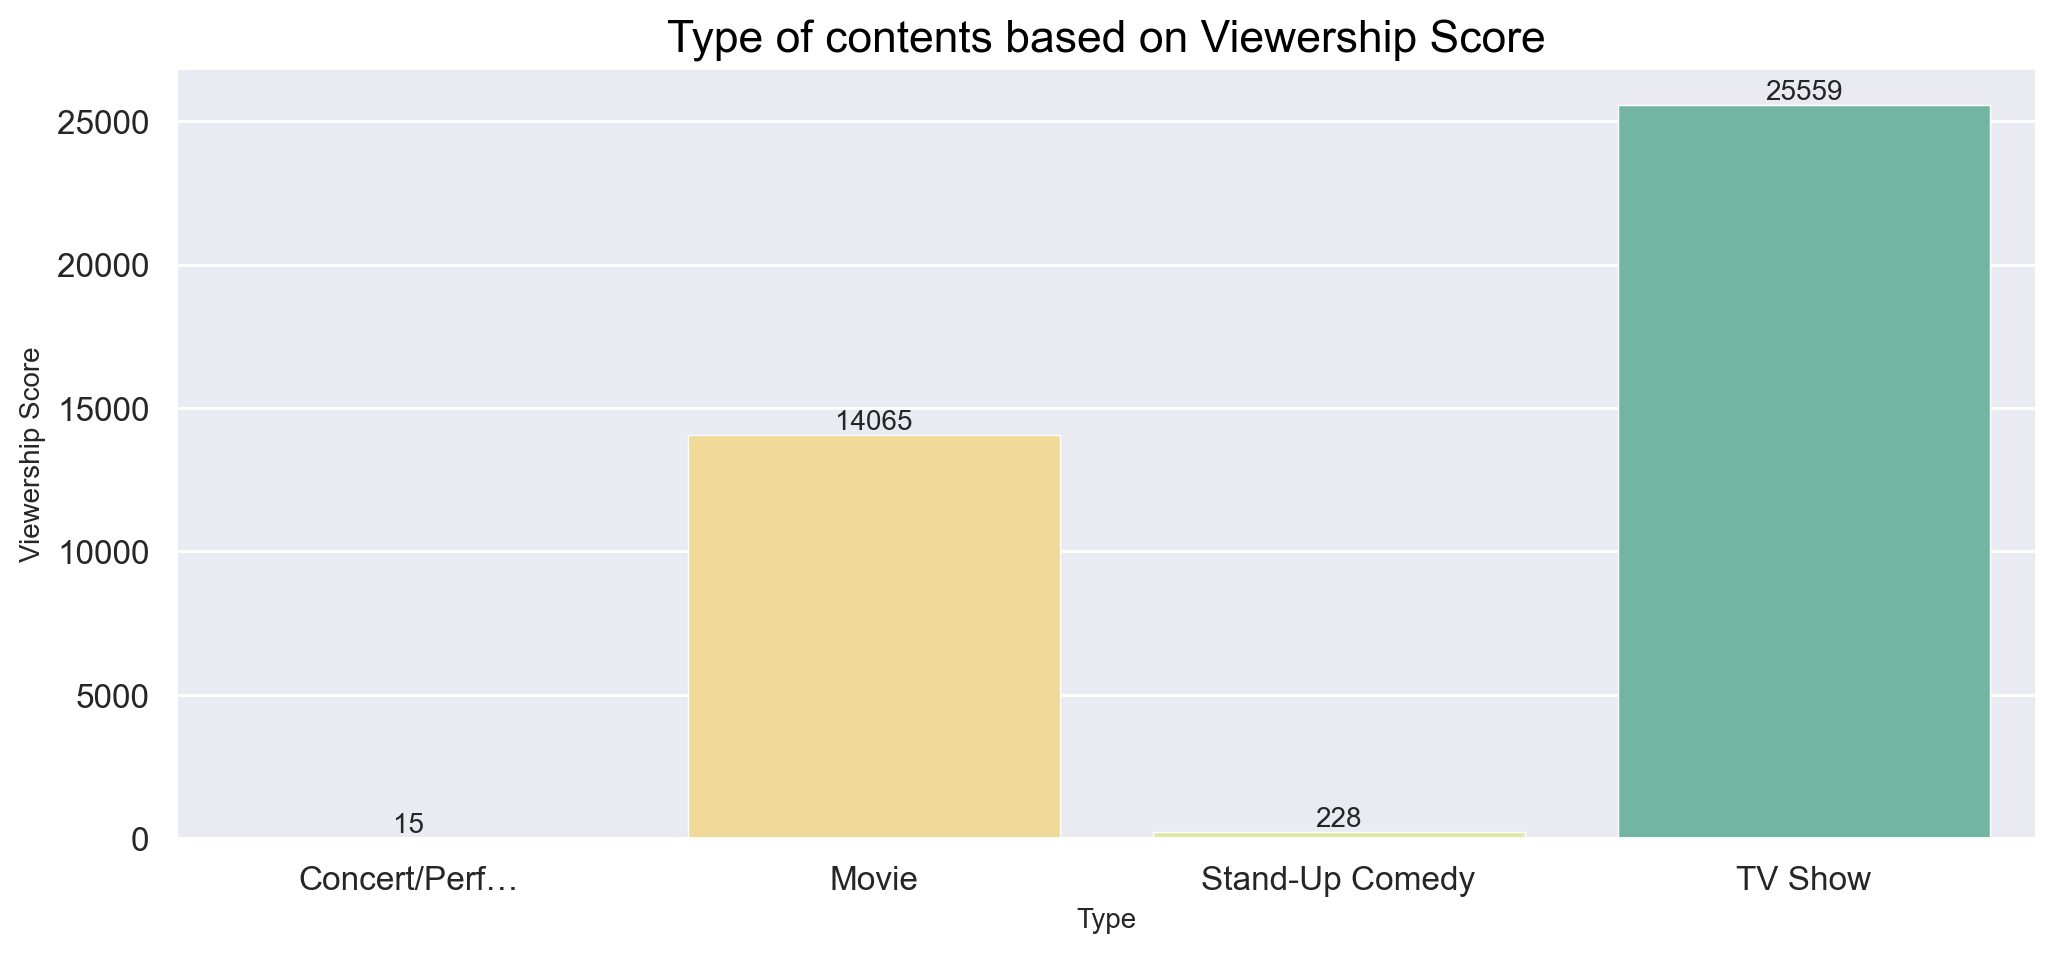

In [26]:
z = df1.groupby(['Type'], as_index = False)['Viewership Score'].sum()
plt.figure(figsize = (12,5), dpi = 200)
ax = sns.barplot(x = 'Type', y = 'Viewership Score', data = z, palette = "Spectral")
for bars in ax.containers:
    ax.bar_label(bars)
    
plt.title('Type of contents based on Viewership Score', size = 16)    
plt.show()

<b> TV Shows is most popular based on Viwership score

## Conclusion

Highest number of movies released on Netflix, which is 355 and in the year of 2021 which is 165, 175 movies released in Netflix non exclusive which is the highest number of movie released in Netflix non exclusive. In Netflix, non exclusive content is 21% based on viwership score But the tv shows is highest number on netfllix exclusive which is 222 and according to viwership score, tv shows is most popular on netflix